In [ ]:
 # Install PySpark
!pip install pyspark

In [ ]:
# Import required libraries
from pyspark import SparkConf, SparkContext
import random
import time

# Create Spark configuration
conf = SparkConf()

# Set application name
conf.setAppName("Distributed-Matrix-PageRank")

# Run Spark locally using all available CPU cores
conf.setMaster("local[*]")

# Create Spark Context
sc = SparkContext.getOrCreate(conf=conf)

# Reduce unnecessary Spark messages
sc.setLogLevel("WARN")

print("Spark started successfully!")
print("Spark version:", sc.version)

Spark started successfully!
Spark version: 4.0.4


In [ ]:
# ============================================================
# PROJECT PARAMETERS
# ============================================================

# Number of documents in the web graph
NUM_DOCUMENTS = 5000

# Minimum outgoing links per document
MIN_LINKS = 2

# Maximum outgoing links per document
MAX_LINKS = 8

# PageRank damping factor
DAMPING = 0.85

# Maximum number of iterations
MAX_ITERATIONS = 100

# Convergence threshold
TOLERANCE = 1e-6

# Number of Spark partitions
NUM_PARTITIONS = 8

print("Project parameters configured successfully!")
print("Number of documents:", NUM_DOCUMENTS)
print("Number of partitions:", NUM_PARTITIONS)
print("Damping factor:", DAMPING)
print("Maximum iterations:", MAX_ITERATIONS)
print("Convergence tolerance:", TOLERANCE)

Project parameters configured successfully!
Number of documents: 5000
Number of partitions: 8
Damping factor: 0.85
Maximum iterations: 100
Convergence tolerance: 1e-06


In [ ]:
# ============================================================
# CELL 4: GENERATE DISTRIBUTED WEB GRAPH
# ============================================================

# Create document IDs
documents = list(range(NUM_DOCUMENTS))


# Function to generate outgoing links
def generate_links(document_id):
    """
    Generate random outgoing links for each document.
    """

    # Randomly select the number of links
    number_of_links = random.randint(
        MIN_LINKS,
        MAX_LINKS
    )

    links = set()

    # Generate unique links
    while len(links) < number_of_links:

        destination = random.randint(
            0,
            NUM_DOCUMENTS - 1
        )

        # Avoid linking a document to itself
        if destination != document_id:
            links.add(destination)

    return document_id, list(links)


# Start measuring graph creation time
start_time = time.time()


# Create the distributed RDD
graph = (
    sc.parallelize(
        documents,
        NUM_PARTITIONS
    )
    .map(generate_links)
    .partitionBy(NUM_PARTITIONS)
    .persist()
)


# Force Spark to create the RDD
graph_count = graph.count()


# Calculate graph creation time
graph_creation_time = time.time() - start_time


# Display information
print("=" * 60)
print("DISTRIBUTED WEB GRAPH CREATED")
print("=" * 60)

print("Number of documents:", graph_count)
print("Number of partitions:", graph.getNumPartitions())
print(
    "Graph creation time:",
    round(graph_creation_time, 4),
    "seconds"
)


# Display first 5 graph records
print("\nSample graph entries:")
print("-" * 60)

for document, links in graph.take(5):
    print(
        "Document",
        document,
        "->",
        links
    )

DISTRIBUTED WEB GRAPH CREATED
Number of documents: 5000
Number of partitions: 8
Graph creation time: 6.2632 seconds

Sample graph entries:
------------------------------------------------------------
Document 0 -> [3042, 4035, 205, 2641, 1626, 2783]
Document 8 -> [1120, 1281, 1873, 818]
Document 16 -> [2156, 1110, 824, 3835, 1020, 3934]
Document 24 -> [778, 1391, 561, 1460, 2042]
Document 32 -> [2370, 2922, 2508, 241, 4795]


In [ ]:
# ============================================================
# CELL 5: INITIALIZE PAGERANK VALUES
# ============================================================

# Each document initially receives an equal PageRank value
initial_rank = 1.0 / NUM_DOCUMENTS


# Create PageRank RDD
# Format:
# (Document_ID, PageRank)
pagerank = (
    graph
    .mapValues(lambda links: initial_rank)
    .persist()
)


# Force Spark to create the RDD
pagerank_count = pagerank.count()


# Display information
print("=" * 60)
print("PAGERANK VECTOR INITIALIZED")
print("=" * 60)

print("Number of documents:", pagerank_count)
print("Initial PageRank per document:", initial_rank)


# Display first 5 PageRank values
print("\nSample PageRank values:")
print("-" * 60)

for document, rank in pagerank.take(5):
    print(
        "Document",
        document,
        "-> PageRank:",
        rank
    )

PAGERANK VECTOR INITIALIZED
Number of documents: 5000
Initial PageRank per document: 0.0002

Sample PageRank values:
------------------------------------------------------------
Document 0 -> PageRank: 0.0002
Document 8 -> PageRank: 0.0002
Document 16 -> PageRank: 0.0002
Document 24 -> PageRank: 0.0002
Document 32 -> PageRank: 0.0002


In [ ]:
# ============================================================
# CELL 6: DISTRIBUTED PAGERANK ITERATION - CORRECTED
# ============================================================

# Store convergence information
convergence_history = []

# Store iteration execution times
iteration_times = []

# Start total execution time
total_start_time = time.time()


# ------------------------------------------------------------
# PAGERANK ITERATIONS
# ------------------------------------------------------------

for iteration in range(1, MAX_ITERATIONS + 1):

    # Start timer
    iteration_start_time = time.time()


    # ========================================================
    # STEP 1: JOIN GRAPH WITH CURRENT PAGERANK
    # ========================================================

    joined = graph.join(pagerank)


    # ========================================================
    # STEP 2: DISTRIBUTE PAGERANK TO OUTGOING LINKS
    # ========================================================

    contributions = joined.flatMap(
        lambda x: [
            (
                destination,
                x[1][1] / len(x[1][0])
            )
            for destination in x[1][0]
        ]
    )


    # ========================================================
    # STEP 3: SUM INCOMING CONTRIBUTIONS
    # ========================================================

    summed_contributions = (
        contributions
        .reduceByKey(lambda a, b: a + b)
    )


    # ========================================================
    # STEP 4: APPLY DAMPING FACTOR
    # ========================================================

    new_pagerank = (
        summed_contributions
        .mapValues(
            lambda rank:
            (1 - DAMPING) / NUM_DOCUMENTS
            + DAMPING * rank
        )
    )


    # ========================================================
    # STEP 5: KEEP ALL DOCUMENTS
    # ========================================================

    # Documents without incoming links receive only
    # the teleportation component.

    teleportation = (
        graph
        .mapValues(
            lambda links:
            (1 - DAMPING) / NUM_DOCUMENTS
        )
    )


    new_pagerank = (
        teleportation
        .leftOuterJoin(
            summed_contributions
        )
        .mapValues(
            lambda x:
            x[0] +
            (
                DAMPING * x[1]
                if x[1] is not None
                else 0.0
            )
        )
        .persist()
    )


    # ========================================================
    # STEP 6: CALCULATE CONVERGENCE
    # ========================================================

    rank_difference = (
        pagerank
        .join(new_pagerank)
        .map(
            lambda x:
            abs(x[1][0] - x[1][1])
        )
        .sum()
    )


    # Store convergence value
    convergence_history.append(rank_difference)


    # Calculate iteration time
    iteration_time = (
        time.time() - iteration_start_time
    )

    iteration_times.append(iteration_time)


    # Remove previous PageRank RDD
    pagerank.unpersist()


    # Update PageRank
    pagerank = new_pagerank


    # Display iteration information
    print(
        "Iteration:",
        iteration,
        "| Difference:",
        format(rank_difference, ".10f"),
        "| Time:",
        format(iteration_time, ".4f"),
        "seconds"
    )


    # ========================================================
    # STEP 7: CHECK CONVERGENCE
    # ========================================================

    if rank_difference < TOLERANCE:

        print("\nPageRank converged!")
        print(
            "Converged at iteration:",
            iteration
        )

        break


# Calculate total execution time
total_execution_time = (
    time.time() - total_start_time
)


# ============================================================
# FINAL INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("PAGERANK CALCULATION COMPLETED")
print("=" * 60)

print(
    "Total execution time:",
    round(total_execution_time, 4),
    "seconds"
)

print(
    "Iterations performed:",
    len(convergence_history)
)

Iteration: 1 | Difference: 0.3270516667 | Time: 3.5537 seconds
Iteration: 2 | Difference: 0.1284092418 | Time: 2.4438 seconds
Iteration: 3 | Difference: 0.0536888622 | Time: 4.9787 seconds
Iteration: 4 | Difference: 0.0222705933 | Time: 3.4701 seconds
Iteration: 5 | Difference: 0.0091763595 | Time: 2.8124 seconds
Iteration: 6 | Difference: 0.0037376753 | Time: 1.9860 seconds
Iteration: 7 | Difference: 0.0015478701 | Time: 2.0976 seconds
Iteration: 8 | Difference: 0.0006544849 | Time: 3.1285 seconds
Iteration: 9 | Difference: 0.0002758913 | Time: 1.9648 seconds
Iteration: 10 | Difference: 0.0001150840 | Time: 1.9358 seconds
Iteration: 11 | Difference: 0.0000476195 | Time: 1.8335 seconds
Iteration: 12 | Difference: 0.0000202904 | Time: 1.9008 seconds
Iteration: 13 | Difference: 0.0000086399 | Time: 1.7443 seconds
Iteration: 14 | Difference: 0.0000036520 | Time: 2.1319 seconds
Iteration: 15 | Difference: 0.0000015315 | Time: 2.6998 seconds
Iteration: 16 | Difference: 0.0000006559 | Time: 

In [ ]:
# ============================================================
# CELL 7: FIND TOP 10 PAGERANKED DOCUMENTS
# ============================================================

# Sort documents by PageRank in descending order
top_documents = (
    pagerank
    .sortBy(
        lambda x: x[1],
        ascending=False
    )
    .take(10)
)


# ============================================================
# DISPLAY TOP 10 DOCUMENTS
# ============================================================

print("=" * 60)
print("TOP 10 DOCUMENTS BY PAGERANK")
print("=" * 60)

print(
    "\nRank\tDocument ID\tPageRank"
)

print("-" * 60)


for position, (document, rank) in enumerate(
    top_documents,
    start=1
):

    print(
        position,
        "\t",
        document,
        "\t\t",
        format(rank, ".10f")
    )

TOP 10 DOCUMENTS BY PAGERANK

Rank	Document ID	PageRank
------------------------------------------------------------
1 	 2598 		 0.0006032306
2 	 2121 		 0.0006009472
3 	 398 		 0.0005656724
4 	 4628 		 0.0005501172
5 	 1859 		 0.0005497036
6 	 285 		 0.0005419430
7 	 3562 		 0.0005368628
8 	 2852 		 0.0005310988
9 	 3672 		 0.0005289513
10 	 3417 		 0.0005258902


In [ ]:
# ============================================================
# CELL 8: PERFORMANCE STATISTICS
# ============================================================

print("=" * 60)
print("PERFORMANCE STATISTICS")
print("=" * 60)

# Number of documents
print(
    "Number of documents:",
    NUM_DOCUMENTS
)

# Number of Spark partitions
print(
    "Number of Spark partitions:",
    NUM_PARTITIONS
)

# Damping factor
print(
    "Damping factor:",
    DAMPING
)

# Number of iterations
print(
    "Iterations performed:",
    len(convergence_history)
)

# Total execution time
print(
    "Total PageRank execution time:",
    round(
        total_execution_time,
        4
    ),
    "seconds"
)

# Average iteration time
average_iteration_time = (
    sum(iteration_times)
    / len(iteration_times)
)

print(
    "Average iteration time:",
    round(
        average_iteration_time,
        4
    ),
    "seconds"
)

# Final convergence difference
print(
    "Final convergence difference:",
    format(
        convergence_history[-1],
        ".10f"
    )
)

# PageRank sum
total_rank = pagerank.values().sum()

print(
    "Total PageRank:",
    format(
        total_rank,
        ".10f"
    )
)

print("=" * 60)

PERFORMANCE STATISTICS
Number of documents: 5000
Number of Spark partitions: 8
Damping factor: 0.85
Iterations performed: 16
Total PageRank execution time: 40.5576 seconds
Average iteration time: 2.5285 seconds
Final convergence difference: 0.0000006559
Total PageRank: 1.0000000000


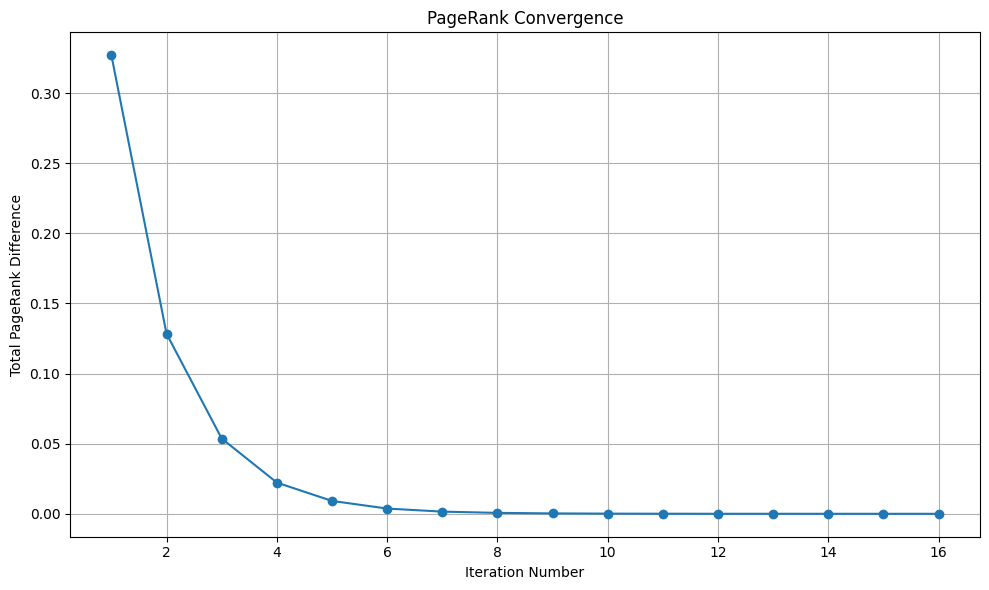

In [ ]:
# ============================================================
# CELL 9: PAGERANK CONVERGENCE GRAPH
# ============================================================

import matplotlib.pyplot as plt


# Create iteration numbers
iterations = list(
    range(
        1,
        len(convergence_history) + 1
    )
)


# Create convergence plot
plt.figure(figsize=(10, 6))

plt.plot(
    iterations,
    convergence_history,
    marker='o'
)

plt.xlabel("Iteration Number")

plt.ylabel(
    "Total PageRank Difference"
)

plt.title(
    "PageRank Convergence"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 10: FINAL PROJECT VALIDATION
# ============================================================

print("=" * 70)
print("DISTRIBUTED MATRIX PAGERANK - FINAL VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. SPARK INFORMATION
# ------------------------------------------------------------

print("\n1. SPARK CONFIGURATION")
print("-" * 70)

print("Spark version:", sc.version)
print("Master:", sc.master)


# ------------------------------------------------------------
# 2. GRAPH INFORMATION
# ------------------------------------------------------------

print("\n2. DISTRIBUTED WEB GRAPH")
print("-" * 70)

print("Number of documents:", graph.count())
print("Number of partitions:", graph.getNumPartitions())


# ------------------------------------------------------------
# 3. PAGERANK INFORMATION
# ------------------------------------------------------------

print("\n3. PAGERANK")
print("-" * 70)

print("Damping factor:", DAMPING)
print("Iterations performed:", len(convergence_history))

print(
    "Final convergence difference:",
    format(
        convergence_history[-1],
        ".10f"
    )
)


# ------------------------------------------------------------
# 4. PAGERANK VALIDATION
# ------------------------------------------------------------

print("\n4. PAGERANK VALIDATION")
print("-" * 70)

total_rank = pagerank.values().sum()

print(
    "Sum of all PageRank values:",
    format(
        total_rank,
        ".10f"
    )
)

if abs(total_rank - 1.0) < 0.01:
    print("PageRank validation: PASSED")
else:
    print("PageRank validation: CHECK REQUIRED")


# ------------------------------------------------------------
# 5. CONVERGENCE VALIDATION
# ------------------------------------------------------------

print("\n5. CONVERGENCE VALIDATION")
print("-" * 70)

if convergence_history[-1] < TOLERANCE:
    print("Convergence status: PASSED")
    print(
        "Final difference is below tolerance:",
        TOLERANCE
    )
else:
    print("Convergence status: NOT REACHED")


# ------------------------------------------------------------
# 6. PERFORMANCE
# ------------------------------------------------------------

print("\n6. PERFORMANCE")
print("-" * 70)

print(
    "Total execution time:",
    round(
        total_execution_time,
        4
    ),
    "seconds"
)

print(
    "Average iteration time:",
    round(
        average_iteration_time,
        4
    ),
    "seconds"
)


# ------------------------------------------------------------
# 7. TOP DOCUMENT
# ------------------------------------------------------------

print("\n7. HIGHEST-RANKED DOCUMENT")
print("-" * 70)

top_document = top_documents[0]

print(
    "Document ID:",
    top_document[0]
)

print(
    "PageRank:",
    format(
        top_document[1],
        ".10f"
    )
)


# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PROJECT VALIDATION COMPLETED SUCCESSFULLY")
print("=" * 70)

DISTRIBUTED MATRIX PAGERANK - FINAL VALIDATION

1. SPARK CONFIGURATION
----------------------------------------------------------------------
Spark version: 4.0.4
Master: local[*]

2. DISTRIBUTED WEB GRAPH
----------------------------------------------------------------------
Number of documents: 5000
Number of partitions: 8

3. PAGERANK
----------------------------------------------------------------------
Damping factor: 0.85
Iterations performed: 16
Final convergence difference: 0.0000006559

4. PAGERANK VALIDATION
----------------------------------------------------------------------
Sum of all PageRank values: 1.0000000000
PageRank validation: PASSED

5. CONVERGENCE VALIDATION
----------------------------------------------------------------------
Convergence status: PASSED
Final difference is below tolerance: 1e-06

6. PERFORMANCE
----------------------------------------------------------------------
Total execution time: 40.5576 seconds
Average iteration time: 2.5285 seconds

7. 